Dan Lagria, 7130170

COSC 4P69

Feb 16, 2026

A1

In [34]:
# Change this to change the ratio between label and unlabel
# For stage 5
label_size = 0.5

# Stage 1

In [ ]:
# GetData.py
# Functions to get and preprocess CIFAR-10 data
# including data augmentation and normalization

import pickle as p
import numpy as np

# Function to unpickle data
# sourced from https://www.cs.toronto.edu/~kriz/cifar.html
def unpickle(file):
    with open(file, 'rb') as fo:
        dict = p.load(fo, encoding='bytes')
    return dict

def create_random_labeled_categories(int_size):
    arr = np.arange(int_size)
    np.random.shuffle(arr)
    return arr

# For sigmoid normalization
def data_to_Min_Max(data):
    data_min = np.min(data, axis=0)
    data_max = np.max(data, axis=0)
    data_range = data_max - data_min
    # Avoid division by zero
    data_range[data_range == 0] = 1
    data_normalized = (data - data_min) / data_range
    return data_normalized

# For tanh normalization
def data_to_Z_score(data):
    data_mean = np.mean(data, axis=0)
    data_std = np.std(data, axis=0)
    # Avoid division by zero
    data_std[data_std == 0] = 1
    data_standardized = (data - data_mean) / data_std
    return data_standardized

def flip_image_data_horizontal(data):
    data_reshaped = data.reshape(-1, 3, 32, 32)
    # Flip horizontally
    data_flipped = data_reshaped[:, :, :, ::-1]
    data_flipped_reshaped = data_flipped.reshape(-1, 3072)
    return data_flipped_reshaped

def flip_image_data_vertical(data):
    data_reshaped = data.reshape(-1, 3, 32, 32)
    # Flip vertically
    data_flipped = data_reshaped[:, :, ::-1, :]
    data_flipped_reshaped = data_flipped.reshape(-1, 3072)
    return data_flipped_reshaped

def random_noise(data, noise_level=0.1):
    noise = np.random.normal(0, noise_level, data.shape)
    data_noisy = data + noise
    # Clip values to be in valid range [0, 255] for image data
    data_noisy = np.clip(data_noisy, 0, 255)
    return data_noisy

def augment_data(data,mutation_chance=0.1):
    augmented_data = []
    for img in data:
        if np.random.rand() < mutation_chance:
            mutation_type = np.random.choice(['horizontal_flip', 'vertical_flip', 'noise'])
            if mutation_type == 'horizontal_flip':
                img = flip_image_data_horizontal(img.reshape(1, -1)).reshape(-1)
            elif mutation_type == 'vertical_flip':
                img = flip_image_data_vertical(img.reshape(1, -1)).reshape(-1)
            elif mutation_type == 'noise':
                img = random_noise(img.reshape(1, -1)).reshape(-1)
        augmented_data.append(img)
    return np.array(augmented_data)
# Functions to retrieve data
def get_cifar10_data():
    return data_numpy, labels_numpy
def get_unlabeled_data():
    return unlabeled_train_data, unlabeled_train_labels
def get_train_data():
    return train_data, train_labels
def get_validation_data():
    return validation_data, validation_labels
def get_test_data():
    return test_data, test_labels
def get_labeled_unlabeled_indices():
    return labeled_train_indices, unlabeled_train_indices
def get_labeled_data():
    return labeled_train_data, labeled_train_labels
# file path of data Using batch 1
# Don't shuffle data for consistent results, use another batch file for more testing
# unpickle the data
data = None
for i in range(1, 5):
  file_path = f'cifar-10-batches-py/data_batch_{i}'
  # unpickle the data
  data_dict = unpickle(file_path)
  if data is None:
    data = np.array(data_dict[b'data'])
    label = np.array(data_dict[b'labels'])
  else:
    data = np.vstack((data, np.array(data_dict[b'data'])))
    label = np.hstack((label, np.array(data_dict[b'labels'])))
size = len(data)
test_size = size // 10
validation_size = size // 10
# separate to test, validation, and train sets
test_data = data[:test_size]
test_labels = label[:test_size]
validation_data = data[test_size:test_size+validation_size]
validation_labels = label[test_size:test_size+validation_size]

train_data = data[test_size+validation_size:]
train_labels = label[test_size+validation_size:]

# create labeled and unlabeled sets
train_size = len(train_data)
labeled_train_size = int(label_size * train_size)
labeled_indices = create_random_labeled_categories(train_size)

# copy first 20% of the shuffled indices to labeled set
labeled_train_indices = labeled_indices[:labeled_train_size]
labeled_train_data = train_data[labeled_train_indices]
labeled_train_labels = np.array(train_labels)[labeled_train_indices]

unlabeled_train_indices = labeled_indices[labeled_train_size:]
unlabeled_train_data = train_data[unlabeled_train_indices]
unlabeled_train_labels = np.array(train_labels)[unlabeled_train_indices]

def extend_with_augmented_data(data, labels, mutation_chance=0.1):
    # Generate augmented data
    augmented_data = augment_data(data, mutation_chance)
    extended_data = np.vstack((data, augmented_data))
    extended_labels = np.hstack((labels, labels))
    return extended_data, extended_labels
def augment_data_with_z_score(data,mutation_chance=0.1):
  augmented_data = augment_data(data, mutation_chance)
  augment_data_z_score = data_to_Z_score(augmented_data)
  return augment_data_z_score
def compare_normalization_methods(data):
  min_max_normalized = data_to_Min_Max(data)
  z_score_normalized = data_to_Z_score(data)
  print("Min-Max Normalization:")
  print(min_max_normalized[1][:5].astype(np.float32))
  print("Z-Score Normalization:")
  print(z_score_normalized[1][:5].astype(np.float32))
  print("Original Data:")
  print(data[1][:5].astype(np.float32))
  # print first 5

In [36]:
data_copy = np.copy(data)
compare_normalization_methods(data_copy)

Min-Max Normalization:
[0.6039216  0.49411765 0.4117647  0.4        0.49019608]
Z-Score Normalization:
[ 0.3147302  -0.05934079 -0.3634064  -0.41365808 -0.10304075]
Original Data:
[154. 126. 105. 102. 125.]


# Stage 2 Network Architecture: Design a feedforward neural network

In [37]:
import tensorflow as tf

size = 3072
output = 10
# use tensor flow for weights
def model_builder (initiallize, activation_func, input, out):
  model = tf.keras.Sequential([
    tf.keras.layers.Dense(512, activation=activation_func, input_shape=(input,)), # each pixel
    tf.keras.layers.Dense(256, activation=activation_func),
    tf.keras.layers.Dense(out, activation='softmax')
  ])
  return model


In [38]:
# cross entropy
def cross_entropy_loss(predicted, actual):
    if actual.ndim == 1:
        actual = tf.one_hot(actual, depth=10)
    e = 1e-5  # Small constant for numerical stability
    predicted = tf.clip_by_value(predicted, e, 1.0 - e)  # Clip predictions to avoid log(0)
    loss = -tf.reduce_mean(tf.reduce_sum(actual * tf.math.log(predicted), axis=1))
    return loss

# version 1 from Stage2.NN
# def cross_entropy_loss(predicted, actual):
#     e = 1e-5  # Small constant for numerical stability
#     predicted = t.clip_by_value(predicted, e, 1.0 - e)  # Clip predictions to avoid log(0)
#     loss = -np.mean(np.sum(actual * np.log(predicted), axis=1))
#     return loss

# Stage 2 Forward and activations



In [39]:
# Run this one for Z_score, the rest of code uses this
def train (model, X, Y, val_X, val_Y, epochs=50, batch_size=None, learning_rate=0.01, alpha=0.9,mutation=0.10):
  best_val_loss = float('inf')
  if batch_size is None:
    batch_size = len(X)//10
  optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate, momentum=alpha)
  vw = {w.name: tf.zeros_like(w) for w in model.trainable_variables}
  vb = {b.name: tf.zeros_like(b) for b in model.trainable_variables}
  history = []
  history_val = []
  patience = 0
  for epoch in range(epochs):
    indicies = np.random.permutation(len(X))
    X = X[indicies]
    Y = Y[indicies]
    # batch training
    for i in range(0, len(X), batch_size):
      b_X = X[i:i+batch_size]
      b_Y = Y[i:i+batch_size]
      # 10% chance to augment
      if epoch > 1:
        b_X = augment_data_with_z_score(b_X,mutation_chance=mutation)
      else:
        b_X = data_to_Z_score(b_X)
      with tf.GradientTape() as tape:
        predicted = model(b_X)
        loss = cross_entropy_loss(predicted, b_Y)
      # calculate gradient
      gradient = tape.gradient(loss, model.trainable_variables)
      optimizer.apply_gradients(zip(gradient, model.trainable_variables))
    train_pred = model(data_to_Z_score(X), training=False)
    val_pred = model(data_to_Z_score(val_X), training=False)

    train_loss = cross_entropy_loss(train_pred, Y).numpy()
    val_loss = cross_entropy_loss(val_pred, val_Y).numpy()

    history.append(train_loss)
    history_val.append(val_loss)

    # stop if increasing
    if epoch > (epochs//5):
        mean_val =np.mean(history_val[-1])
        std_val = np.std(history_val[-1])
        if val_loss > mean_val + std_val:
          break
    previous_loss = val_loss
  return model, history, history_val

def test_model(model,X,Y):
    X = data_to_Z_score(X)
    if isinstance(Y, list):
      Y = np.array(Y)
    if len(Y.shape) == 1:
      Y = tf.one_hot(Y, depth=10)
    predicted = model(X, training=False)
    loss = cross_entropy_loss(predicted, Y).numpy()
    accuracy = tf.reduce_mean(tf.cast(tf.equal(tf.argmax(predicted, axis=1), tf.argmax(Y, axis=1)), tf.float32)).numpy()
    return loss, accuracy

Commented out, since z score is better

In [40]:
# # Run this one for minimax, the rest of code uses this
# def train (model, X, Y, val_X, val_Y, epochs=50, batch_size=None, learning_rate=0.01, alpha=0.9,mutation=0.10):
#   best_val_loss = float('inf')
#   if batch_size is None:
#     batch_size = len(X)//10
#   optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate, momentum=alpha)
#   vw = {w.name: tf.zeros_like(w) for w in model.trainable_variables}
#   vb = {b.name: tf.zeros_like(b) for b in model.trainable_variables}
#   history = []
#   history_val = []
#   patience = 0
#   for epoch in range(epochs):
#     indicies = np.random.permutation(len(X))
#     X = X[indicies]
#     Y = Y[indicies]
#     # batch training
#     for i in range(0, len(X), batch_size):
#       b_X = X[i:i+batch_size]
#       b_Y = Y[i:i+batch_size]
#       # 10% chance to augment
#       b_X = data_to_Min_Max(b_X)
#       with tf.GradientTape() as tape:
#         predicted = model(b_X)
#         loss = cross_entropy_loss(predicted, b_Y)
#       # calculate gradient
#       gradient = tape.gradient(loss, model.trainable_variables)
#       optimizer.apply_gradients(zip(gradient, model.trainable_variables))
#     train_pred = model(data_to_Min_Max(X), training=False)
#     val_pred = model(data_to_Min_Max(val_X), training=False)

#     train_loss = cross_entropy_loss(train_pred, Y).numpy()
#     val_loss = cross_entropy_loss(val_pred, val_Y).numpy()

#     history.append(train_loss)
#     history_val.append(val_loss)

#     # stop if increasing
#     if epoch > (epochs//5):
#         mean_val =np.mean(history_val[-1])
#         std_val = np.std(history_val[-1])
#         if val_loss > mean_val + std_val:
#           break
#     previous_loss = val_loss
#   return model, history, history_val
#   def test_model(model,X,Y):
#     X = data_to_Min_Max(X)
#     if isinstance(Y, list):
#       Y = np.array(Y)
#     if len(Y.shape) == 1:
#       Y = tf.one_hot(Y, depth=10)
#     predicted = model(X, training=False)
#     loss = cross_entropy_loss(predicted, Y).numpy()
#     accuracy = tf.reduce_mean(tf.cast(tf.equal(tf.argmax(predicted, axis=1), tf.argmax(Y, axis=1)), tf.float32)).numpy()
#     return loss, accuracy

# Initialize Data and test

In [41]:
from tensorflow.keras.utils import to_categorical
def to_Categorical(labels, num_classes):
    return to_categorical(labels, num_classes=num_classes)

In [42]:
data_input,data_labeled = get_labeled_data()
validation_data, validation_labels = get_validation_data()
test_data, test_labels = get_test_data()

# exted with augmentation
# data_input, data_labeled = extend_with_augmented_data(data_input, data_labeled)
# data_input =  data_to_Z_score(data_input)

# validation_data = data_to_Z_score (validation_data)
print("Data and labels retrieved successfully.")

Data and labels retrieved successfully.


In [43]:
# run for min_max
# test_data =  data_to_Min_Max(test_data)

In [44]:
# Run for z_score
test_data =  data_to_Z_score(test_data)

In [45]:
# Run only once
data_labeled = np.copy(data_labeled)
validation_labels = np.copy(validation_labels)
test_labels = np.copy(test_labels)

data_labeled = to_Categorical(data_labeled, output)
validation_labels = to_Categorical(validation_labels, output)

In [46]:
model = model_builder(tf.keras.initializers.HeNormal, 'relu', size, output)
print("Model built successfully.")
# train (model,
#   X,
#   Y, val_X,
#   val_Y, epochs=50,
#   batch_size=None,              batch size set it to any bugs out if greater than sample size
#   learning_rate=0.01,           learning rate base is 0.01
#    alpha=0.9): Momentun crap
trained_model, history, history_val = train(model, data_input, data_labeled, validation_data, validation_labels,epochs=50,learning_rate=0.001,mutation = 0)


Model built successfully.


# Plot stage 2

In [47]:
def plot_history(history, history_val):
    import matplotlib.pyplot as plt
    epochs = range(1, len(history)+1)

    plt.figure(figsize=(8,5))
    plt.plot(epochs, history, label='Train Loss', marker='o')
    plt.plot(epochs, history_val, label='Validation Loss', marker='x')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.grid(True)
    plt.show()
# plot_history(history,history_val)

In [48]:
# test accuracy
# did this one for z_score
loss_train_test, accuracy_train_test = test_model(trained_model, test_data, test_labels)
print('Test loss:', loss_train_test)
print('Test accuracy:', accuracy_train_test)

Test loss: 1.6015202
Test accuracy: 0.44175


In [49]:

# test accuracy
# this one for minmax

# Commented out use z_score for the rest

# loss_train_test, accuracy_train_test = test_model(trained_model, test_data, test_labels)
# print('Test loss:', loss_train_test)
# print('Test accuracy:', accuracy_train_test)

# Stage 2 F

In [50]:
import time as t
seeds = [1, 123, 12345]
results = []

def seed_training(seeds):
  for seed in seeds:
    data_in = np.copy(data_input)
    data_lab = np.copy(data_labeled)
    time_start = t.time()
    tf.random.set_seed(seed)
    np.random.seed(seed)
    idx = np.random.permutation(len(data_input))
    # random input
    data_in = data_in[idx]
    data_lab = data_lab[idx]
    # random indicies
    model = model_builder(tf.keras.initializers.HeNormal, 'relu', size, output)
    trained_model, history, history_val = train(model, data_in, data_lab, validation_data, validation_labels)
    loss_train_test, accuracy_train_test = test_model(trained_model, test_data, test_labels)
    time_taken = t.time() - time_start
    results.append({
        'seed': seed,
        'test_loss': loss_train_test,
        'test_acc': accuracy_train_test,
        'time_taken': time_taken
    })
  return results
results = seed_training(seeds)
# average accuracy with standard deviation
average_acc = np.mean([result['test_acc'] for result in results])
std_dev_acc = np.std([result['test_acc'] for result in results])
print(f"Average accuracy: {average_acc:.4f}")
print(f"Standard deviation of accuracy: {std_dev_acc:.4f}")
print(f"time taken: {np.mean([result['time_taken'] for result in results])}")

Average accuracy: 0.4877
Standard deviation of accuracy: 0.0049
time taken: 318.2698763211568


# Stage 3

In [51]:
def l2_regularization(model, l=0.001):
  l2 = 0
  for layer in model.layers:
    for weight in layer.weights:
      if 'bias' not in weight.name: # bugged out on me
        l2 += tf.reduce_sum(tf.square(weight))
  l2 *= l/2
  return l2
def cross_entropy_loss_with_l2(predicted, actual, model, l=0.001):
  if actual.ndim == 1:
    actual = tf.one_hot(actual, depth=10)
  return cross_entropy_loss(predicted, actual) + l2_regularization(model, l)
def train_stage_3 (model, X, Y, val_X, val_Y, epochs=50, batch_size=None, learning_rate=0.01, alpha=0.9, k_epoch=5,decay_rate = 0.95, l=1e-5,mutation=0):
  if batch_size is None:
    batch_size = len(X)//10
  best_val_loss = float('inf')
  optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate, momentum=alpha)
  vw = {w.name: tf.zeros_like(w) for w in model.trainable_variables}
  vb = {b.name: tf.zeros_like(b) for b in model.trainable_variables}
  history = []
  history_val = []
  patience = 0
  original_learning_rate = learning_rate
  for epoch in range(epochs):
    # step decay
    if epoch > 0 and epoch % k_epoch == 0:
      learning_rate = original_learning_rate * decay_rate**epoch
      optimizer.learning_rate = learning_rate
    indicies = np.random.permutation(len(X))
    X = X[indicies]
    Y = Y[indicies]
    # batch training
    for i in range(0, len(X), batch_size):
      b_X = X[i:i+batch_size]
      b_Y = Y[i:i+batch_size]
      # 0% chance to augment
      if epoch > 1 and mutation != 0:
        b_X = augment_data_with_z_score(b_X)
      else:
        b_X = data_to_Z_score(b_X)
      with tf.GradientTape() as tape:
        predicted = model(b_X)
        loss = cross_entropy_loss_with_l2(predicted, b_Y,model, l)
      # calculate gradient
      gradient = tape.gradient(loss, model.trainable_variables)
      optimizer.apply_gradients(zip(gradient, model.trainable_variables))
    train_pred = model(data_to_Z_score(X), training=False)
    val_pred = model(data_to_Z_score(val_X), training=False)

    train_loss = cross_entropy_loss_with_l2(train_pred, Y,model,l).numpy()
    val_loss = cross_entropy_loss_with_l2(val_pred, val_Y,model,l).numpy()

    history.append(train_loss)
    history_val.append(val_loss)

    # stop if increasing
    if epoch > (epochs//5):
        mean_val =np.mean(history_val[-1])
        std_val = np.std(history_val[-1])
        if val_loss > mean_val + std_val:
          break
  return model, history, history_val

Model built successfully.


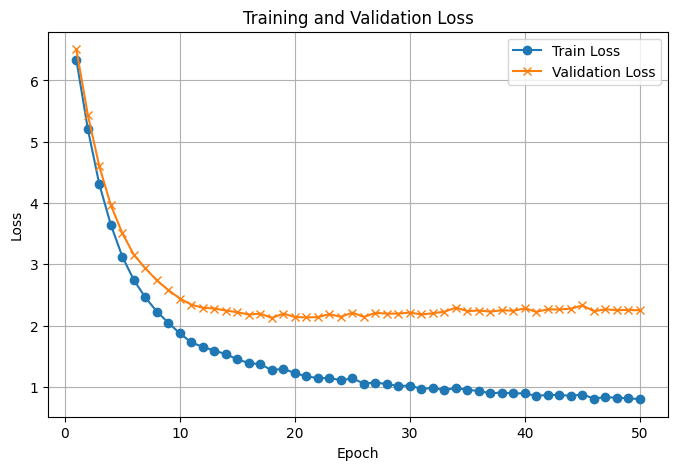

In [52]:
model = model_builder(tf.keras.initializers.HeNormal, 'relu', size, output)
print("Model built successfully.")
# train_stage_3 (model, X, Y, val_X, val_Y, epochs=50, batch_size=None, learning_rate=0.01, alpha=0.9, k_epoch=5,decay_rate = 0.95, l=1e-5):
# step decay 10 = good, 5 = better, 1 = worst
# learning rate = 0.005
# decay rate = 0.9(bad)-> 0.95(good)-> 0.99(bad)-: 0.97,0.6 is really good
# batch size = 30-50 is weirdly fine, 50-100 is bad
# mutation kinda just got added in cuz why not, set it to 0 for now 0.1 gave it 2%
trained_model, history, history_val = train_stage_3(model, data_input, data_labeled, validation_data, validation_labels,epochs=50, batch_size=64, learning_rate=0.005,k_epoch=5,decay_rate=0.97,l=1e-2,mutation=0.0)
plot_history(history,history_val)

In [53]:
# test accuracy lambda = 1e-2
loss_train_test, accuracy_train_test = test_model(trained_model, test_data, test_labels)
print('Test loss:', loss_train_test)
print('Test accuracy:', accuracy_train_test)
# test accuracy = lambda = 1e-3
trained_model, history, history_val = train_stage_3(model, data_input, data_labeled, validation_data, validation_labels,epochs=50, batch_size=64, learning_rate=0.005,k_epoch=5,decay_rate=0.97,l=1e-3,mutation=0.0)
loss_train_test, accuracy_train_test = test_model(trained_model, test_data, test_labels)
print('Test loss:', loss_train_test)
print('Test accuracy:', accuracy_train_test)
# test accuracy = lambda = 1e-4
trained_model, history, history_val = train_stage_3(model, data_input, data_labeled, validation_data, validation_labels,epochs=50, batch_size=64, learning_rate=0.005,k_epoch=5,decay_rate=0.97,l=1e-4,mutation=0.0)
loss_train_test, accuracy_train_test = test_model(trained_model, test_data, test_labels)
print('Test loss:', loss_train_test)
print('Test accuracy:', accuracy_train_test)
# test accuracy = lambda = 1e-5
trained_model, history, history_val = train_stage_3(model, data_input, data_labeled, validation_data, validation_labels,epochs=50, batch_size=64, learning_rate=0.005,k_epoch=5,decay_rate=0.97,l=1e-5,mutation=0.0)
loss_train_test, accuracy_train_test = test_model(trained_model, test_data, test_labels)
print('Test loss:', loss_train_test)
print('Test accuracy:', accuracy_train_test)

Test loss: 1.609979
Test accuracy: 0.50675
Test loss: 2.4754965
Test accuracy: 0.50875
Test loss: 3.14116
Test accuracy: 0.509


KeyboardInterrupt: 

In [54]:
import time as t
seeds = [1, 123, 12345]
results = []

def seed_training_1(seeds):
  for seed in seeds:

    data_in = np.copy(data_input)
    data_lab = np.copy(data_labeled)
    time_start = t.time()
    tf.random.set_seed(seed)
    np.random.seed(seed)
    idx = np.random.permutation(len(data_input))
    # random input
    data_in = data_in[idx]
    data_lab = data_lab[idx]
    model = model_builder(tf.keras.initializers.HeNormal, 'relu', size, output)
    trained_model, history, history_val = train_stage_3(model, data_in, data_lab, validation_data, validation_labels,epochs=50, batch_size=64, learning_rate=0.005,k_epoch=10,decay_rate=0.97,l=1e-3,mutation=0.0)
    loss_train_test, accuracy_train_test = test_model(trained_model, test_data, test_labels)
    time_taken = t.time() - time_start
    results.append({
        'seed': seed,
        'test_loss': loss_train_test,
        'test_acc': accuracy_train_test,
        'time_taken': time_taken,
        'history': history,
        'history_val': history_val

    })
  return results
results_S3 = seed_training_1(seeds)
# average accuracy with standard deviation
average_acc = np.mean([result['test_acc'] for result in results_S3])
std_dev_acc = np.std([result['test_acc'] for result in results_S3])
average_time = np.mean([result['time_taken'] for result in results_S3])

print(f"average time: {average_time:.4f}")
print(f"Average accuracy: {average_acc:.4f}")
print(f"Standard deviation of accuracy: {std_dev_acc:.4f}")

average time: 762.6317
Average accuracy: 0.5008
Standard deviation of accuracy: 0.0038


# Stage 4 B) Augmented

In [55]:
label_data, label_labels = get_labeled_data()
unlabel_data, unlabel_labels = get_unlabeled_data()
val_data, val_label = get_validation_data()
# copy all
label_data = np.copy(label_data)
label_labels = np.copy(label_labels)
unlabel_data = np.copy(unlabel_data)
unlabel_labels = np.copy(unlabel_labels)
val_data = np.copy(val_data)
val_label = np.copy(val_label)
# make augmented version
augmented_data = np.copy(label_data)
augmented_data = augment_data(augmented_data,mutation_chance=1)
augmented_labels = np.copy(label_labels)

In [56]:
def train_stage_4(unlabel_data,a_train,a_label,b_train,b_label, itterations=10):
  unlabel_data = np.copy(unlabel_data)
  a_train = np.copy(a_train)
  a_label = np.copy(a_label)
  # Train 2 separate models on each view
  model_a = model_builder(tf.keras.initializers.HeNormal, 'relu', size, output)
  model_b = model_builder(tf.keras.initializers.HeNormal, 'relu', size, output)
  # best from stage 3
  model_a, _,_ = train_stage_3(model_a, a_train, a_label, validation_data, validation_labels,epochs=50, batch_size=64, learning_rate=0.005,k_epoch=10,decay_rate=0.97,l=1e-3,mutation=0.0)
  model_b, _,_= train_stage_3(model_b, b_train, b_label, validation_data, validation_labels,epochs=50, batch_size=64, learning_rate=0.005,k_epoch=10,decay_rate=0.97,l=1e-3,mutation=0.0)
  for i in range(itterations):
    # 2 unlabeled data classified by each model to generate candidate pseudo-labels
    unlabeled_pred_a = model_a(unlabel_data, training=False)
    unlabeled_pred_b = model_b(unlabel_data, training=False)
    # 3 A pseudo-labeled datapoint added to training set for the low-confidence model if:
    X_a, Y_a, X_b, Y_b, unlabel_data = select_return(unlabel_data, unlabeled_pred_a, unlabeled_pred_b, threshold_H=0.1, threshold_L=0.5)
    # It receives low-entropy (high confidence) prediction from one model AND
    print("debug_shape: ",X_a.shape)
    if X_a.shape[0] > 0:
      a_train = np.concatenate((a_train, X_a), axis=0)
      a_label = np.concatenate((a_label, Y_a), axis=0)
    if X_b.shape[0] > 0:
      b_train = np.concatenate((b_train, X_b), axis=0)
      b_label = np.concatenate((b_label, Y_b), axis=0)
    # change step decay to 1
    model_a,_,_ = train_stage_3(model_a, a_train, a_label, validation_data, validation_labels,epochs=3, batch_size=64, learning_rate=0.005,k_epoch=1,decay_rate=0.97,l=1e-3,mutation=0.0)
    model_b,_,_ = train_stage_3(model_b, b_train, b_label, validation_data, validation_labels,epochs=3, batch_size=64, learning_rate=0.005,k_epoch=1,decay_rate=0.97,l=1e-3,mutation=0.0)
  return model_a, model_b

# cross entropy
def cross_entropy_loss_single(predicted):
    e = 1e-5  # Small constant for numerical stability
    predicted = tf.clip_by_value(predicted, e, 1.0 - e)
    # loss = -tf.sum(predicted * tf.math.log(predicted))
    loss = -tf.math.reduce_sum(predicted * tf.math.log(predicted))
    return loss
def select_return(unlabel_X,prediction_a,prediction_b, threshold_H,threshold_L):
  # storage for adding samples to main training
  X_a = []
  Y_a = []
  X_b = []
  Y_b = []
  remove = []
  p_b = np.argmax(prediction_a, axis=1)
  p_a = np.argmax(prediction_b, axis=1)

  # calculate
  for i in range(len(unlabel_X)):
    entropy_a = cross_entropy_loss_single(prediction_a[i]).numpy()
    entropy_b = cross_entropy_loss_single(prediction_b[i]).numpy()
    sample = unlabel_X[i]
    # print(entropy_a,entropy_b)
    # Part 3
    if entropy_a < threshold_H and entropy_b > threshold_L:
      # add sample
      X_b.append(sample)
      Y_b.append(p_a[i])
      remove.append(i)
    if entropy_b < threshold_H and entropy_a > threshold_L:
      # add sample
      X_a.append(sample)
      Y_a.append(p_b[i])
      remove.append(i)
  # Remove from unlabeled
  unlabel_X = np.delete(unlabel_X, remove, axis=0)
  X_a = np.array(X_a)
  Y_a = np.array(Y_a)
  X_b = np.array(X_b)
  Y_b = np.array(Y_b)
  return X_a, Y_a, X_b, Y_b, unlabel_X


In [57]:
# function to test model
def test_model_co(model_a,model_b,X,Y):
  predict_a = model_a(X, training=False)
  predict_b = model_b(X, training=False)
  average_prediction = (predict_a + predict_b) / 2
  if Y.ndim == 1:
    true_labels = to_Categorical(Y, output)
  else:
    true_labels = Y
  loss = cross_entropy_loss(average_prediction,true_labels).numpy()
  predict_true = np.argmax(average_prediction, axis=1)

  true_labels = np.argmax(true_labels, axis=1)
  accuracy = np.mean(predict_true == true_labels)
  return loss, accuracy

In [58]:
model_a, model_b = train_stage_4(unlabel_data,unlabel_labels,label_data,label_labels,augmented_data,augmented_labels,itterations=5)

TypeError: train_stage_4() got multiple values for argument 'itterations'

In [ ]:
# test accuracy
loss_train_test, accuracy_train_test = test_model_co(model_a,model_b, test_data, test_labels)
print('Test loss:', loss_train_test)
print('Test accuracy:', accuracy_train_test)

In [59]:
import time as t
seeds = [1, 123, 12345]
results = []

def seed_training_2(seeds):
  for seed in seeds:
    time_start = t.time()
    tf.random.set_seed(seed)
    np.random.seed(seed)
    model_a, model_b = train_stage_4(unlabel_data,label_data,label_labels,augmented_data,augmented_labels,itterations=5)
    loss_train_test, accuracy_train_test = test_model_co(model_a,model_b, test_data, test_labels)
    time_taken = t.time() - time_start
    results.append({
        'seed': seed,
        'test_loss': loss_train_test,
        'test_acc': accuracy_train_test,
        'time_taken': time_taken
    })
  return results

In [60]:
results = seed_training_2(seeds)
# average accuracy with standard deviation
average_acc = np.mean([result['test_acc'] for result in results])
std_dev_acc = np.std([result['test_acc'] for result in results])
print(f"Average accuracy: {average_acc:.4f}")
print(f"Standard deviation of accuracy: {std_dev_acc:.4f}")
average_time = np.mean([result['time_taken'] for result in results])
print(average_time)

debug_shape:  (115, 3072)
debug_shape:  (121, 3072)
debug_shape:  (104, 3072)
debug_shape:  (98, 3072)
debug_shape:  (68, 3072)
debug_shape:  (104, 3072)
debug_shape:  (111, 3072)
debug_shape:  (107, 3072)
debug_shape:  (110, 3072)
debug_shape:  (109, 3072)
debug_shape:  (111, 3072)
debug_shape:  (60, 3072)
debug_shape:  (104, 3072)
debug_shape:  (101, 3072)
debug_shape:  (119, 3072)
Average accuracy: 0.4952
Standard deviation of accuracy: 0.0033
2142.009804725647


# Stage 5